# 1. Data Inventory & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import os

RAW_DATA_PATH = pathlib.Path("data/raw")
csv_files = sorted(list(RAW_DATA_PATH.glob("*.csv")))

inventory_data = []

# 1. Loop through files to get counts for the table
for file_path in csv_files:
    df = pd.read_csv(file_path, low_memory=False)

    inventory_data.append(
        {
            "file": file_path.name,
            "size_mb": round(file_path.stat().st_size / (1024 * 1024), 2),
            "rows": len(df),
            "cols": len(df.columns),
        }
    )

inventory_df = pd.DataFrame(inventory_data)

# 2. Print table to verify all years loaded
print("SJPD Dataset Audit:")
display(inventory_df)

SJPD Dataset Audit:


,file,size_mb,rows,cols
0,policecalls2016.csv,67.31,309252,15
1,policecalls2017.csv,68.82,316174,15
2,policecalls2018.csv,70.48,322365,15
3,policecalls2019.csv,70.64,322624,15
4,policecalls2020.csv,65.11,297458,15
5,policecalls2021.csv,67.28,302119,15
6,policecalls2022.csv,66.16,294515,15
7,policecalls2023.csv,64.13,286481,15
8,policecalls2024.csv,43.59,272506,16
9,policecalls2025.csv,48.46,262095,16


# 2. Annual Call Trends

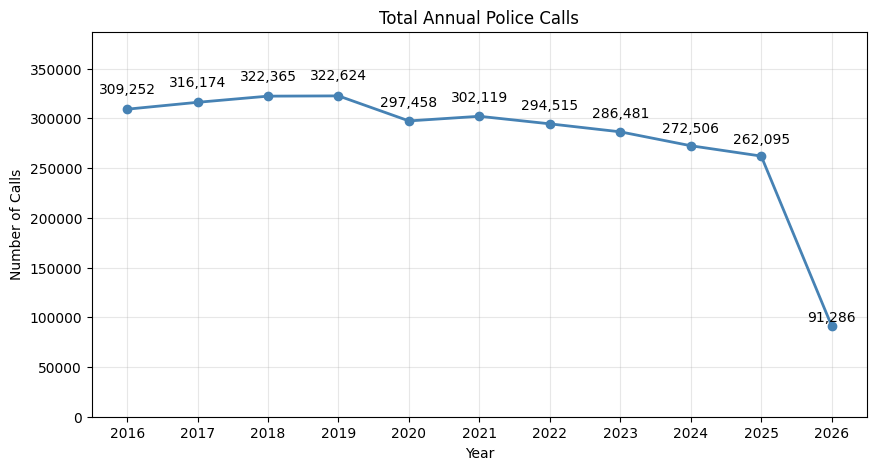

In [2]:
# 1. Get the year from the filename for the X-axis
inventory_df["year"] = inventory_df["file"].str.extract(r"(\d{4})")

plt.figure(figsize=(10, 5))
plt.plot(
    inventory_df["year"],
    inventory_df["rows"],
    marker="o",
    color="steelblue",
    linewidth=2,
)

for i in range(len(inventory_df)):
    plt.text(i, inventory_df.rows[i] * 1.05, f"{inventory_df.rows[i]:,}", ha="center")

# 2. Plot the annual trend of police calls
plt.title("Total Annual Police Calls")
plt.xlabel("Year")
plt.ylabel("Number of Calls")
plt.ylim(0, inventory_df.rows.max() * 1.2)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Daily Volume & Surges

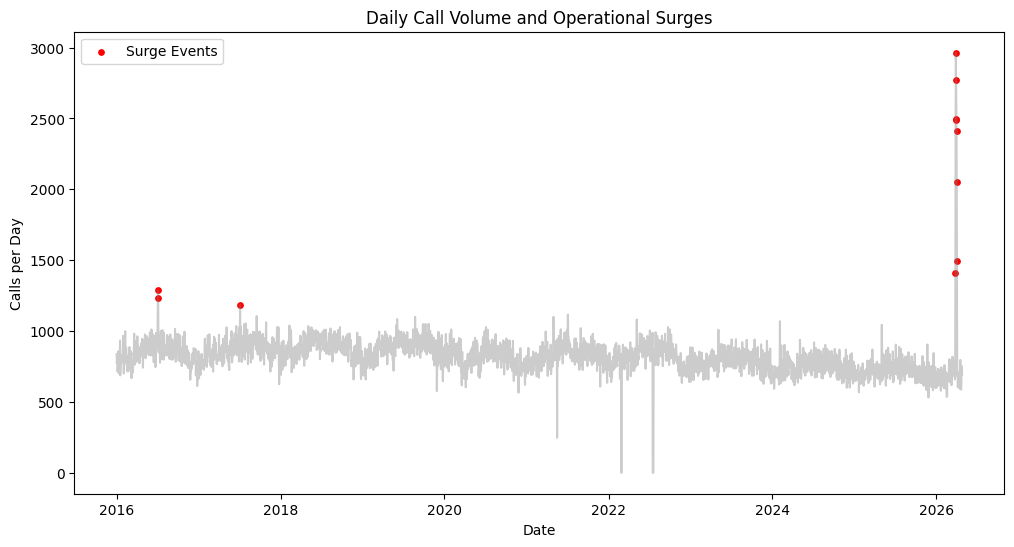

In [3]:
all_dfs = []

for file_path in csv_files:
    df = pd.read_csv(file_path, low_memory=False)
    df["OFFENSE_DATE"] = pd.to_datetime(df["OFFENSE_DATE"], format="mixed")
    all_dfs.append(df[["OFFENSE_DATE"]])

master_df = pd.concat(all_dfs)

# 1. Group calls by day to see the volume
daily_counts = master_df.set_index("OFFENSE_DATE").resample("D").size()

plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts.values, color="gray", alpha=0.4)

# 2. Mark extreme spikes as red outliers (3 std dev)
threshold = daily_counts.mean() + (3 * daily_counts.std())
surges = daily_counts[daily_counts > threshold]

plt.scatter(surges.index, surges.values, color="red", s=15, label="Surge Events")

plt.title("Daily Call Volume and Operational Surges")
plt.xlabel("Date")
plt.ylabel("Calls per Day")
plt.legend()
plt.show()